In [2]:

#Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec  # for complex layouts
import seaborn as sns
import os

sns.set_theme(style="darkgrid")
plt.rcParams["figure.dpi"] = 120

CLEAN_PATH = "../data/cleaned/"
FIGURES_PATH = "../outputs/figures/"
os.makedirs(FIGURES_PATH, exist_ok=True)

print("Libraries imported!")

Libraries imported!


In [3]:

# Load Datasets


co2_emissions  = pd.read_csv(CLEAN_PATH + "co2_emissions_clean.csv")
temp_anomaly   = pd.read_csv(CLEAN_PATH + "temp_anomaly_clean.csv")
energy_mix     = pd.read_csv(CLEAN_PATH + "energy_mix_clean.csv")
carbon_prices  = pd.read_csv(CLEAN_PATH + "carbon_prices_clean.csv", parse_dates=["date"])
climate_events = pd.read_csv(CLEAN_PATH + "climate_events_clean.csv", parse_dates=["date"])

print(" Datasets loaded!")

 Datasets loaded!


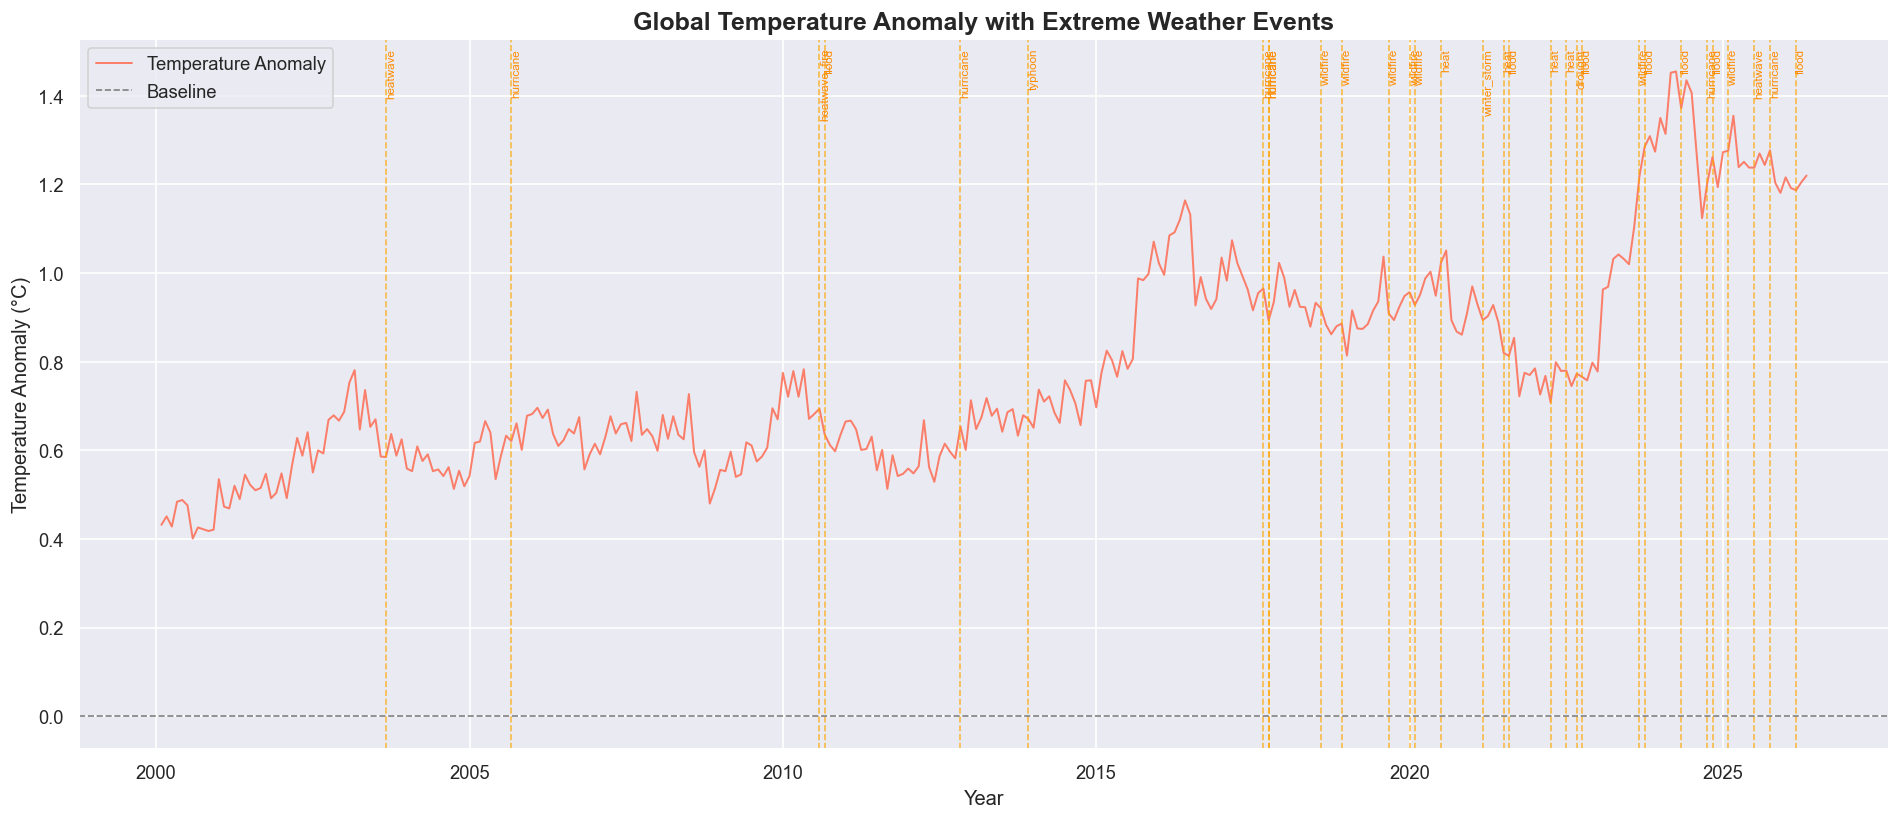

 Panel 1 saved!


In [4]:

# CELL 3: Temperature + Climate Events Overlay

# This chart shows temperature over time AND marks
# when major climate events happened on the same chart

# Filter global temperature
global_temp = temp_anomaly[temp_anomaly["region"] == "Global"].copy()
global_temp["time"] = global_temp["year"] + global_temp["month"] / 12

# Filter only extreme weather events
extreme_events = climate_events[climate_events["is_extreme_weather"] == 1]

fig, ax = plt.subplots(figsize=(16, 7))

# Plot temperature
ax.plot(
    global_temp["time"],
    global_temp["temp_anomaly_c"],
    color="tomato",
    linewidth=1.2,
    alpha=0.8,
    label="Temperature Anomaly"
)

# Mark each extreme weather event with a vertical line
for _, event in extreme_events.iterrows():
    event_year = event["date"].year + event["date"].month / 12
    ax.axvline(
        x=event_year,
        color="orange",
        linewidth=1,
        alpha=0.7,
        linestyle="--"
    )
    # Add event label at the top
    ax.text(
        event_year,
        ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1.2,
        event["event_type"],
        rotation=90,
        fontsize=7,
        color="darkorange",
        va="top"
    )

ax.axhline(0, color="gray", linestyle="--", linewidth=1, label="Baseline")

ax.set_title("Global Temperature Anomaly with Extreme Weather Events", fontsize=15, fontweight="bold")
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Temperature Anomaly (°C)", fontsize=12)
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES_PATH + "07_temperature_with_events.png", dpi=150)
plt.show()
print(" Panel 1 saved!")

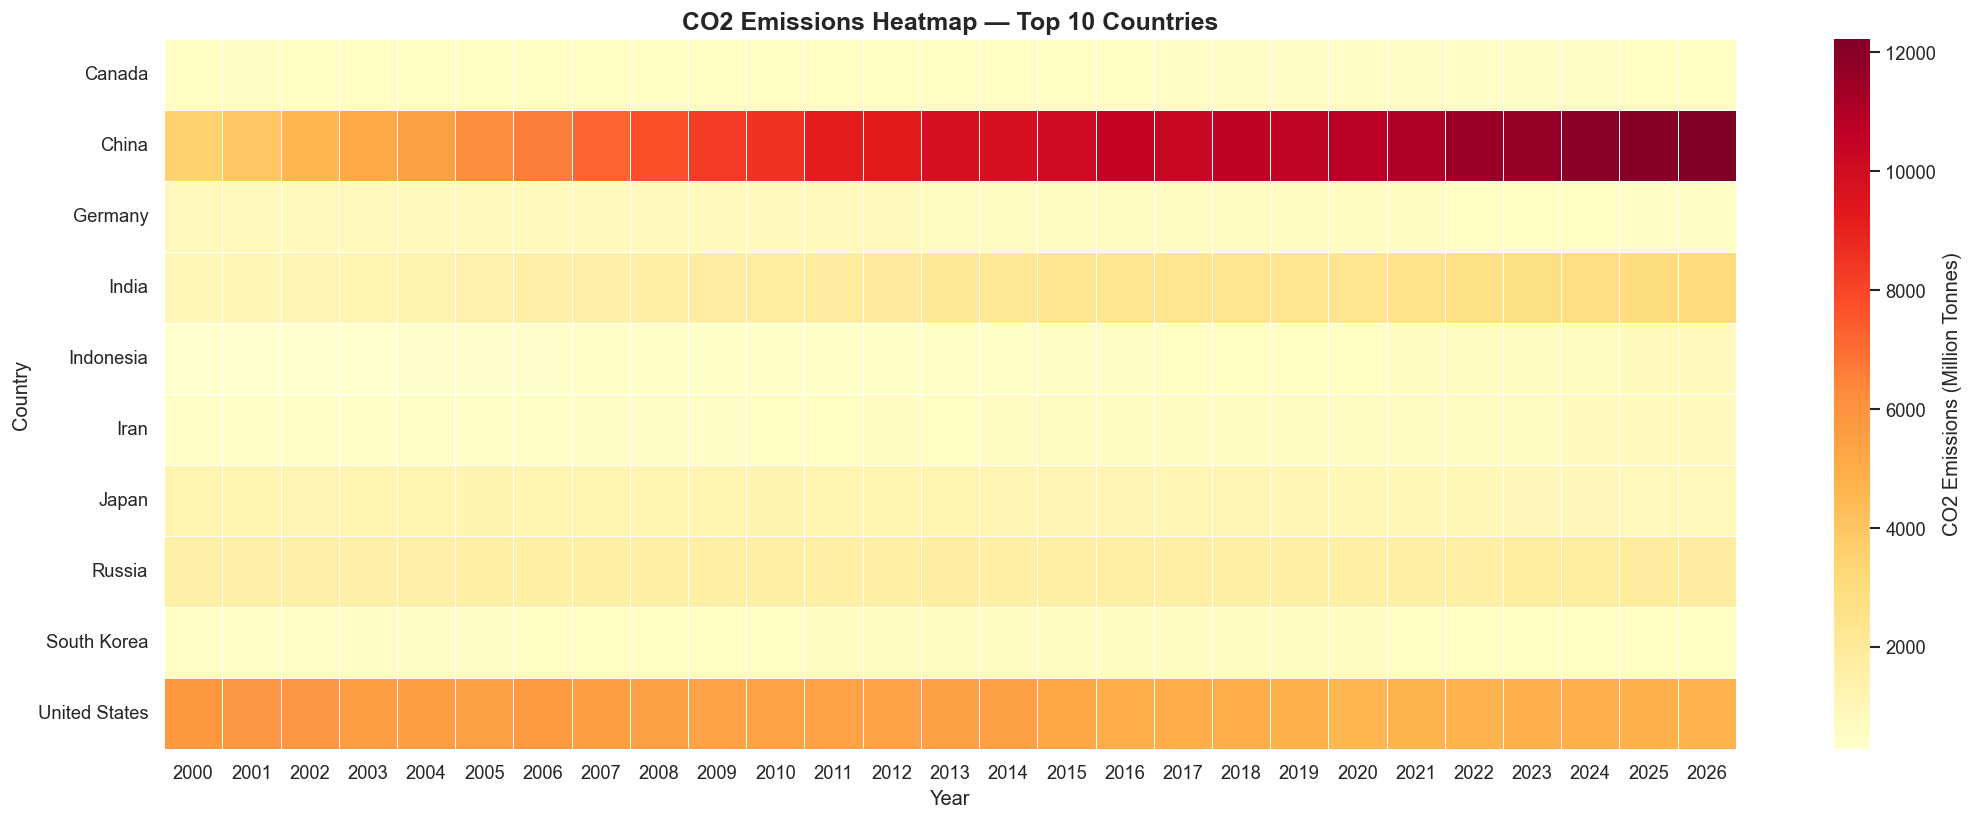

Panel 2 saved!


In [5]:
# CO2 Emissions Heatmap

# A heatmap shows data as colors in a grid
# Rows = countries, Columns = years, Color = CO2 amount

# Get top 10 countries by total emissions
top10 = (
    co2_emissions.groupby("country")["co2_emissions_mt"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index.tolist()
)

# Filter and reshape data into a grid
heatmap_data = (
    co2_emissions[co2_emissions["country"].isin(top10)]
    .pivot_table(index="country", columns="year", values="co2_emissions_mt")
)

fig, ax = plt.subplots(figsize=(18, 7))

sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",        # yellow = low, red = high
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "CO2 Emissions (Million Tonnes)"}
)

ax.set_title("CO2 Emissions Heatmap — Top 10 Countries", fontsize=15, fontweight="bold")
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Country", fontsize=12)

plt.tight_layout()
plt.savefig(FIGURES_PATH + "08_co2_heatmap.png", dpi=150)
plt.show()
print("Panel 2 saved!")

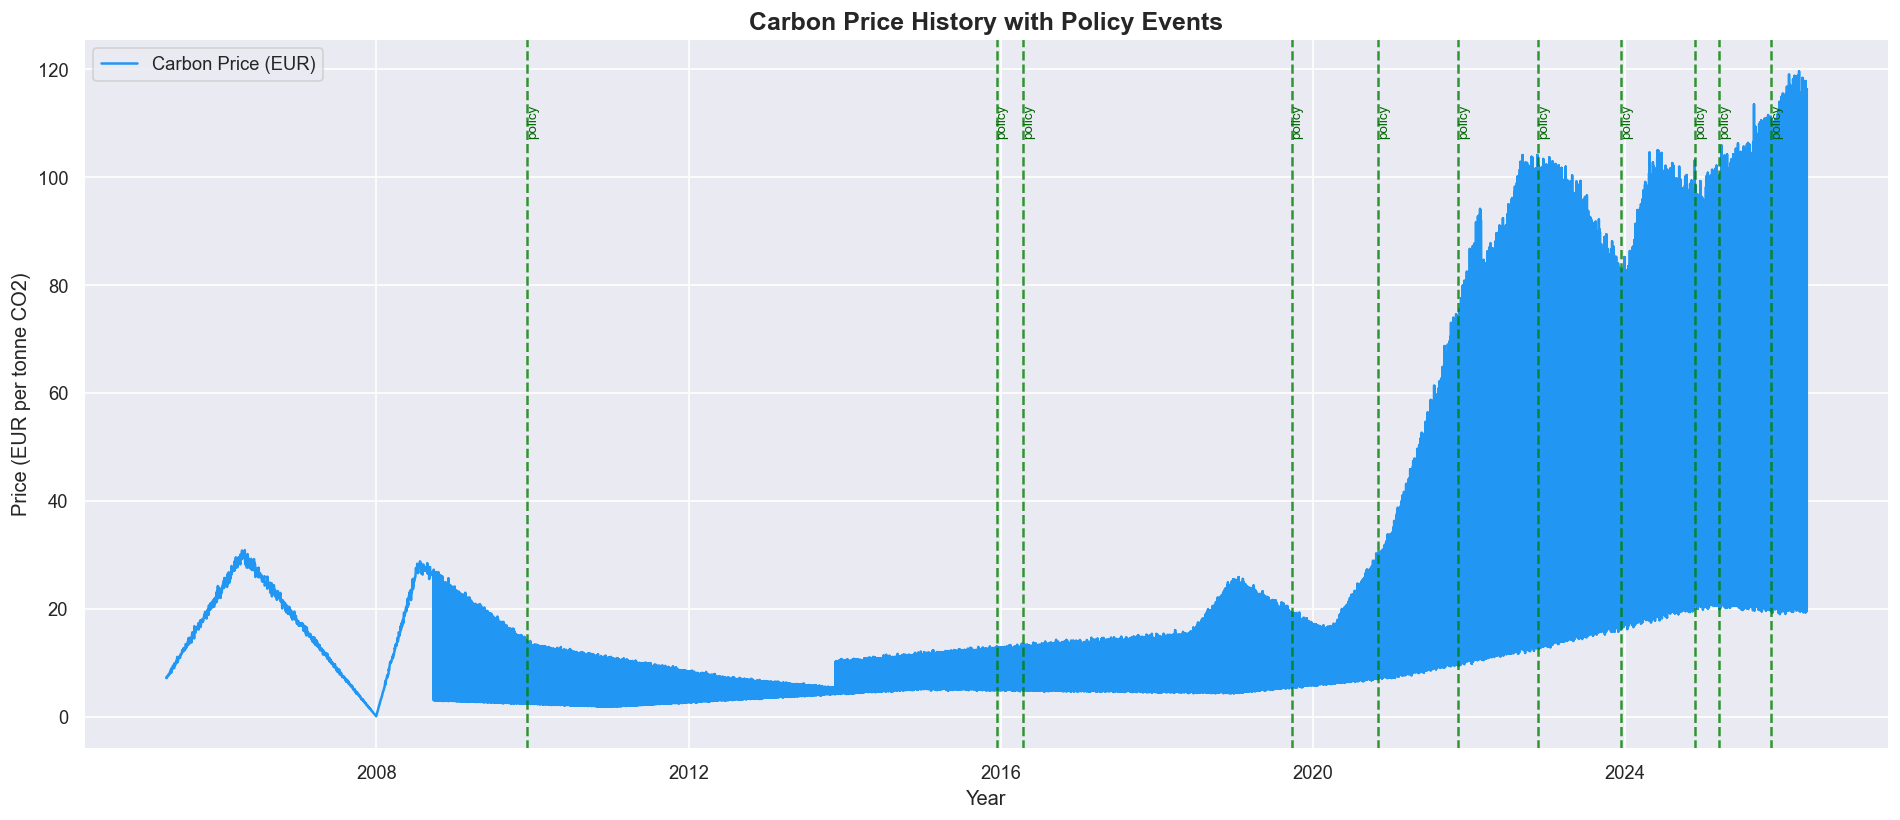

 Panel 3 saved!


In [6]:

# Carbon Price + Policy Events

# This shows carbon price over time and marks
# when major policy decisions happened

# Filter policy events
policy_events = climate_events[climate_events["is_policy"] == 1]

fig, ax = plt.subplots(figsize=(16, 7))

# Plot carbon price
ax.plot(
    carbon_prices["date"],
    carbon_prices["price"],
    color="#2196F3",
    linewidth=1.5,
    label="Carbon Price (EUR)"
)

# Mark policy events
for _, event in policy_events.iterrows():
    ax.axvline(
        x=event["date"],
        color="green",
        linewidth=1.5,
        alpha=0.8,
        linestyle="--"
    )
    ax.text(
        event["date"],
        carbon_prices["price"].max() * 0.95,
        event["event_type"],
        rotation=90,
        fontsize=8,
        color="darkgreen",
        va="top"
    )

ax.set_title("Carbon Price History with Policy Events", fontsize=15, fontweight="bold")
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Price (EUR per tonne CO2)", fontsize=12)
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES_PATH + "09_carbon_price_with_policy.png", dpi=150)
plt.show()
print(" Panel 3 saved!")

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_12364\590003548.py:68: UserWarning: Glyph 9889 (\N{HIGH VOLTAGE SIGN}) missing from font(s) Arial.
  plt.savefig(FIGURES_PATH + "10_full_dashboard.png", dpi=150, bbox_inches="tight")
c:\Users\Lenovo\Documents\climate_change_analysis\Climate-change-analysis\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9889 (\N{HIGH VOLTAGE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


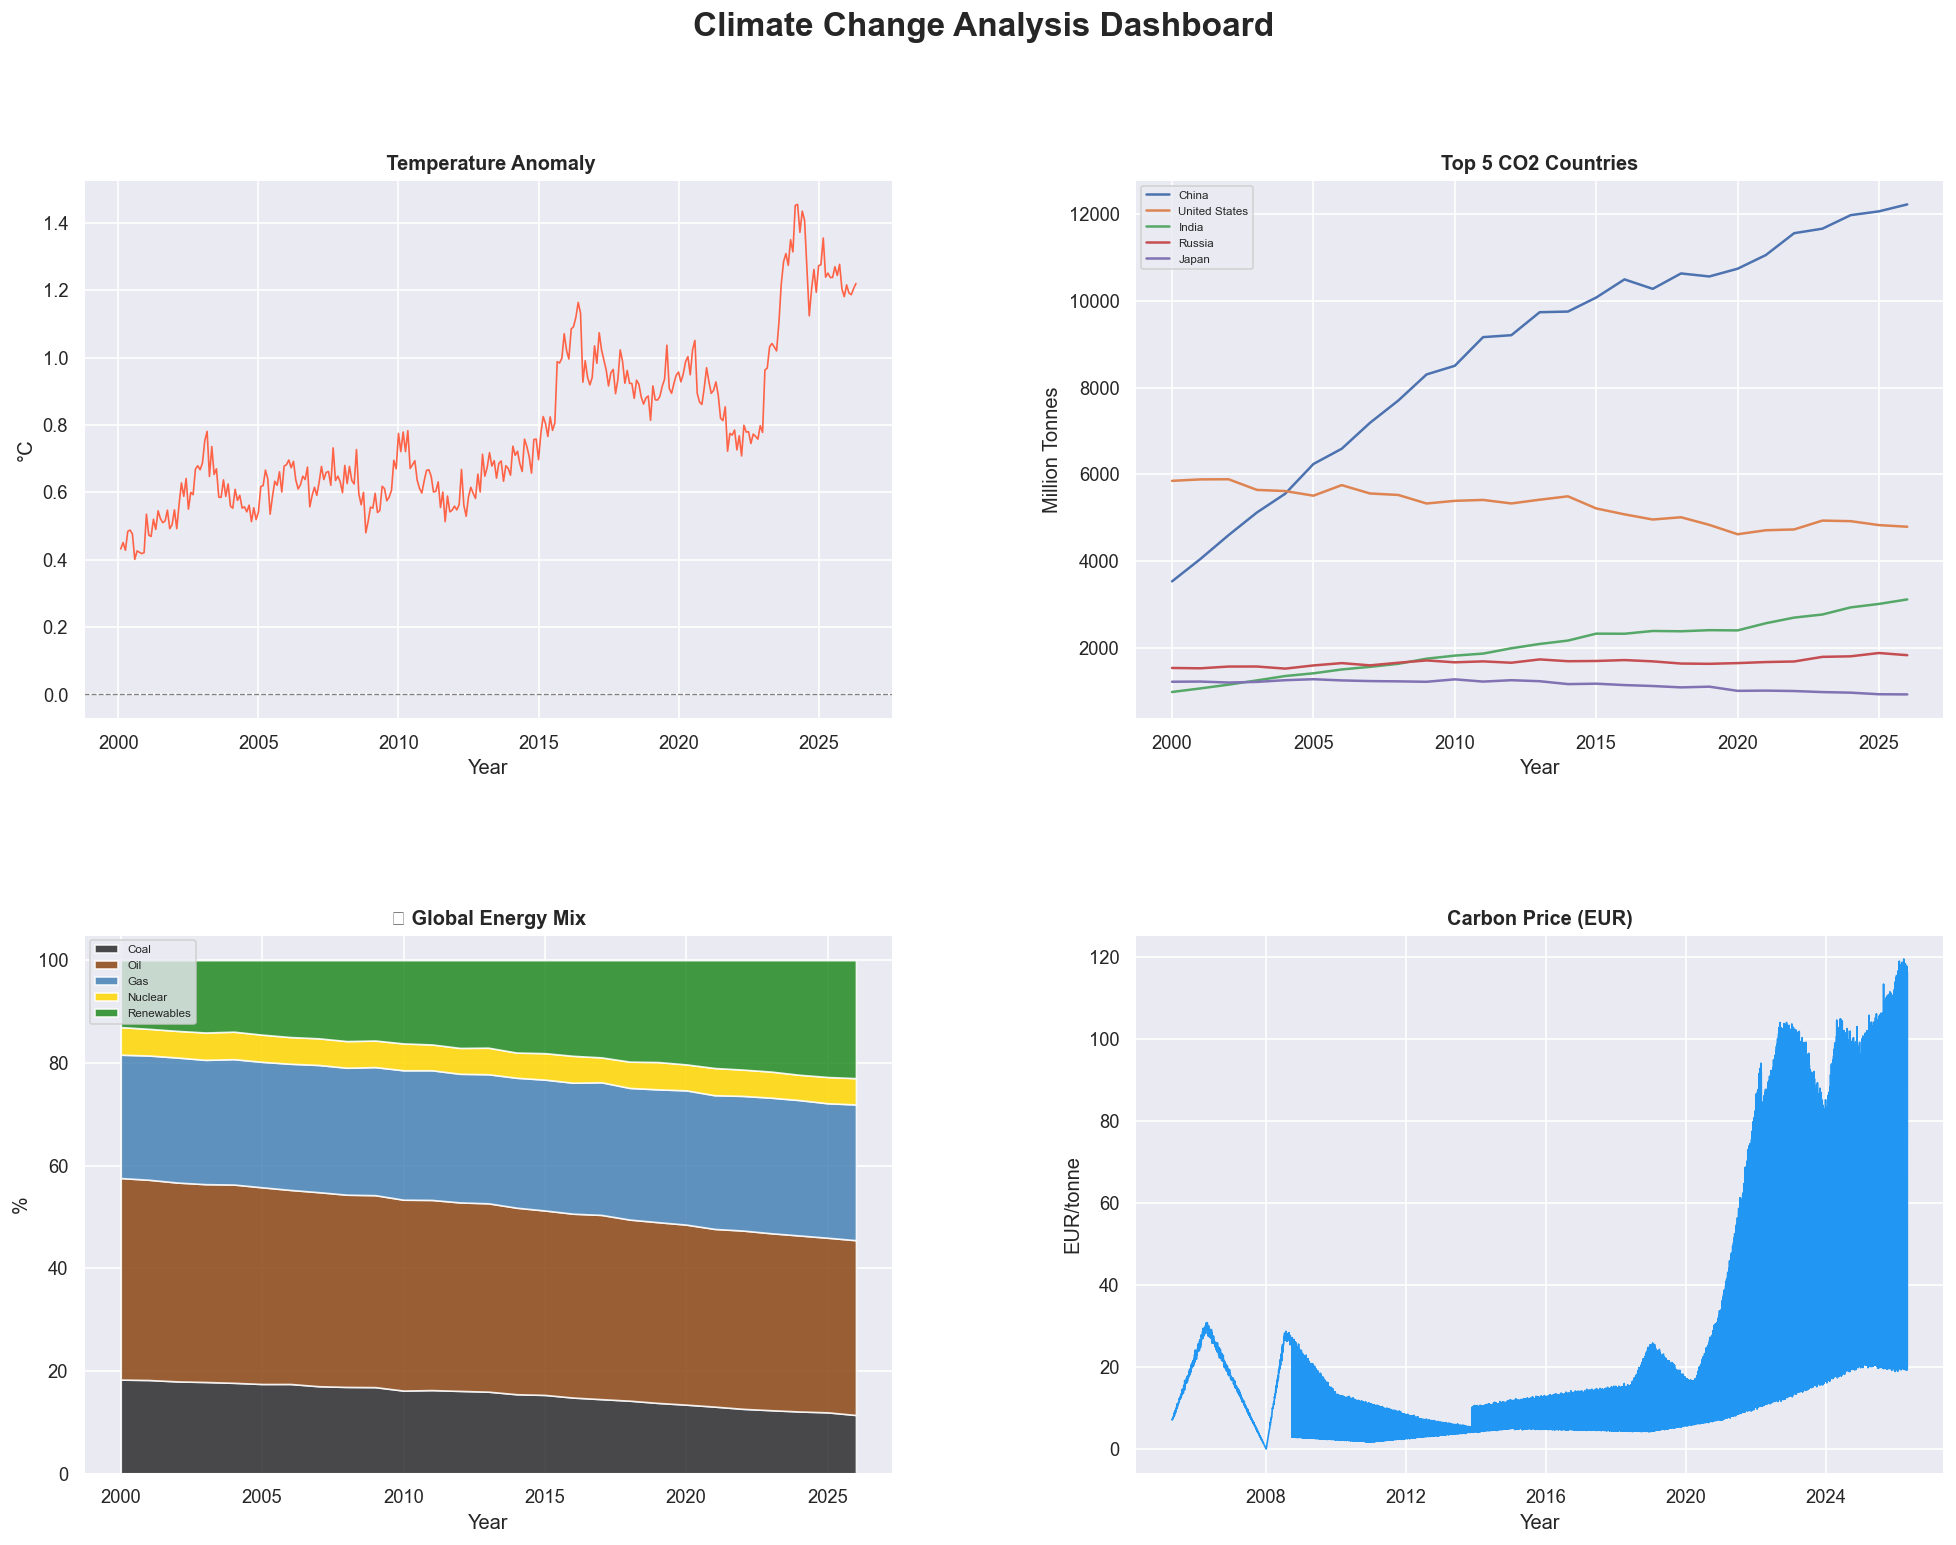

Full dashboard saved!


In [7]:
#  Full Summary Dashboard

# This combines 4 charts into one big figure


fig = plt.figure(figsize=(20, 14))
fig.suptitle("Climate Change Analysis Dashboard", fontsize=20, fontweight="bold", y=0.98)


gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0])  
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0]) 
ax4 = fig.add_subplot(gs[1, 1])  

# --- Top Left: Temperature Anomaly ---
global_temp = temp_anomaly[temp_anomaly["region"] == "Global"].copy()
ax1.plot(
    global_temp["year"] + global_temp["month"] / 12,
    global_temp["temp_anomaly_c"],
    color="tomato", linewidth=1
)
ax1.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax1.set_title(" Temperature Anomaly", fontweight="bold")
ax1.set_xlabel("Year")
ax1.set_ylabel("°C")

# --- Top Right: Top 5 CO2 Countries ---
top5 = (
    co2_emissions.groupby("country")["co2_emissions_mt"]
    .sum().sort_values(ascending=False).head(5).index.tolist()
)
for country in top5:
    d = co2_emissions[co2_emissions["country"] == country]
    ax2.plot(d["year"], d["co2_emissions_mt"], linewidth=1.5, label=country)
ax2.set_title("Top 5 CO2 Countries", fontweight="bold")
ax2.set_xlabel("Year")
ax2.set_ylabel("Million Tonnes")
ax2.legend(fontsize=7)

# --- Bottom Left: Energy Mix ---
energy_yearly = energy_mix.groupby("year")[
    ["coal_pct", "oil_pct", "gas_pct", "nuclear_pct", "renewables_total_pct"]
].mean()
ax3.stackplot(
    energy_yearly.index,
    energy_yearly["coal_pct"],
    energy_yearly["oil_pct"],
    energy_yearly["gas_pct"],
    energy_yearly["nuclear_pct"],
    energy_yearly["renewables_total_pct"],
    labels=["Coal", "Oil", "Gas", "Nuclear", "Renewables"],
    colors=["#2c2c2c", "#8B4513", "#4682B4", "#FFD700", "#228B22"],
    alpha=0.85
)
ax3.set_title("⚡ Global Energy Mix", fontweight="bold")
ax3.set_xlabel("Year")
ax3.set_ylabel("%")
ax3.legend(fontsize=7, loc="upper left")

# --- Bottom Right: Carbon Price ---
ax4.plot(carbon_prices["date"], carbon_prices["price"], color="#2196F3", linewidth=1)
ax4.set_title("Carbon Price (EUR)", fontweight="bold")
ax4.set_xlabel("Year")
ax4.set_ylabel("EUR/tonne")

plt.savefig(FIGURES_PATH + "10_full_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Full dashboard saved!")